In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup estetico per grafici da Tesi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
# 1. Caricamento Metadati
df_meta = pd.read_csv('/work/data/metadata/metadata_final.csv')
df_meta['decade'] = (df_meta['box_office_year'] // 10) * 10
df_meta['decade_label'] = df_meta['decade'].astype(str) + "s"

# 2. Caricamento Risultati LLM
df_llm = pd.read_csv('/work/llm_outputs/DATABASE_TESI_COMPLETO.csv') 
# RIMUOVAMO I DUPLICATI PRIMA DEL MERGE PER EVITARE L'ERRORE "title_x" e "title_y"
df_llm = df_llm.drop(columns=['title', 'domestic_box_office_gross'], errors='ignore')

# Merge
df_full = pd.merge(df_meta, df_llm, on='imdb_id', how='inner')

# Stampiamo l'invariante (che poi non useremo nei grafici)
media_conflitto = df_full['structural_conflict_score'].mean()
print(f"Media globale Conflitto Strutturale (Invariante): {media_conflitto:.2f} su 10")

Media globale Conflitto Strutturale (Invariante): 8.44 su 10


In [3]:
# Mappatura dei soli 5 temi ideologici
temi_ideologici = {
    'force_as_resolution_score': 'Forza/Risoluzione', 
    'institutional_cynicism_score': 'Cinismo Istituzionale', 
    'power_dynamics_score': 'Dinamiche Potere', 
    'extreme_individualism_score': 'Individualismo', 
    'perceived_threat_score': 'Minaccia Percepita'
}

dati_assoluti = []
for _, row in df_full.iterrows():
    for col, label in temi_ideologici.items():
        if pd.notna(row.get(col)):
            dati_assoluti.append({
                'imdb_id': row['imdb_id'],
                'title': row['title'], # Ora funziona!
                'box_office_year': row['box_office_year'],
                'decade_label': row['decade_label'],
                'genre': row['genre'],
                'Tema': label,
                'Score (0-10)': float(row[col])
            })
            
df_assoluto = pd.DataFrame(dati_assoluti)
print(f"Dataset Assoluto pronto: {len(df_assoluto)} valutazioni tematiche estratte.")

Dataset Assoluto pronto: 20499 valutazioni tematiche estratte.


/tmp/ipykernel_395/2704234007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


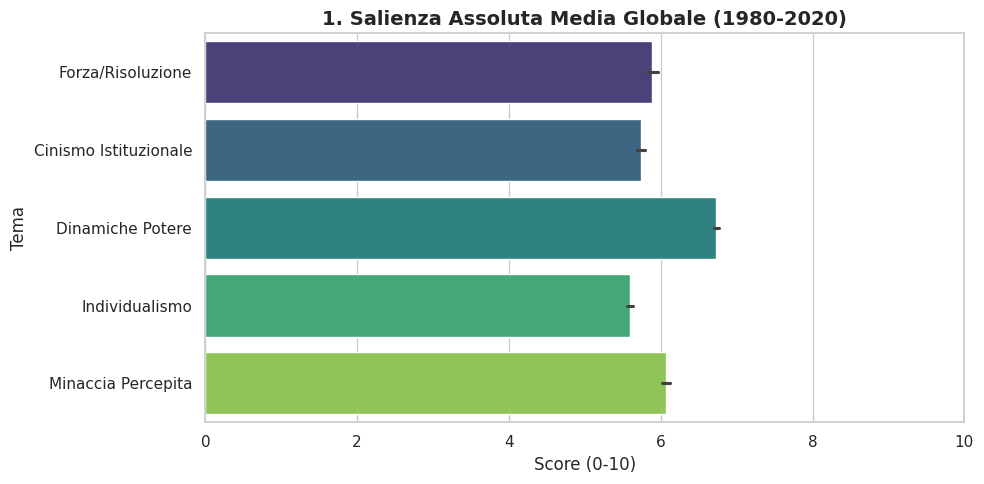

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_assoluto, 
    x='Score (0-10)', 
    y='Tema', 
    estimator=np.mean, 
    errorbar=('ci', 95), 
    palette="viridis", 
    orient='h'
)
plt.title('1. Salienza Assoluta Media Globale (1980-2020)', fontsize=14, fontweight='bold')
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig('07A_plot1_gerarchia.png', dpi=300)
plt.show()

/tmp/ipykernel_395/1945083391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


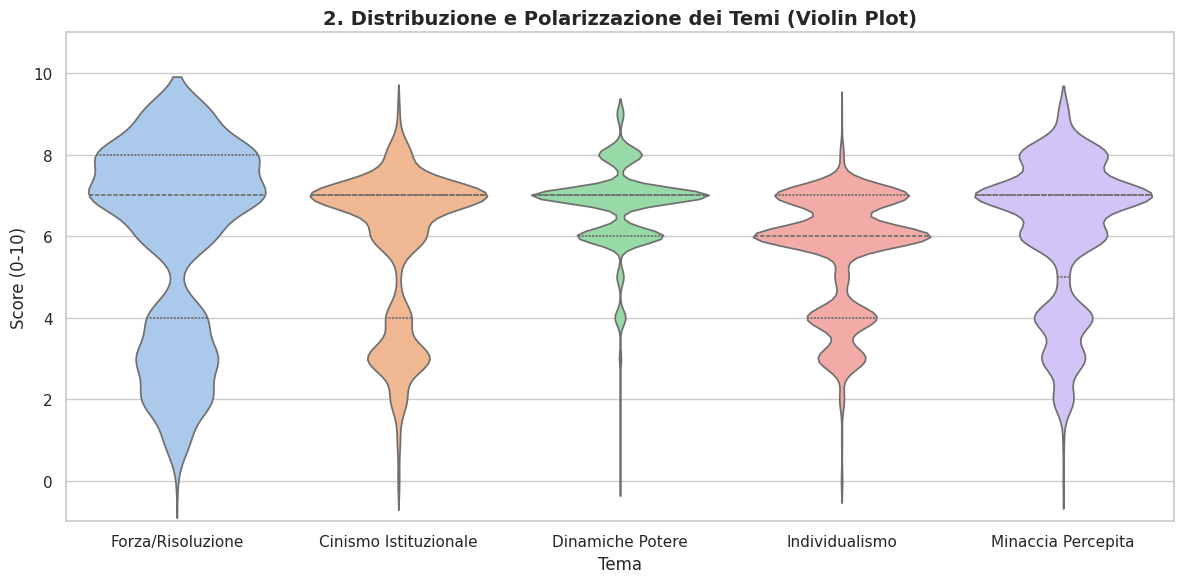

In [5]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_assoluto, 
    x='Tema', 
    y='Score (0-10)', 
    palette="pastel", 
    inner="quartile"
)
plt.title('2. Distribuzione e Polarizzazione dei Temi (Violin Plot)', fontsize=14, fontweight='bold')
plt.ylim(-1, 11)
plt.tight_layout()
plt.savefig('07A_plot2_violin.png', dpi=300)
plt.show()

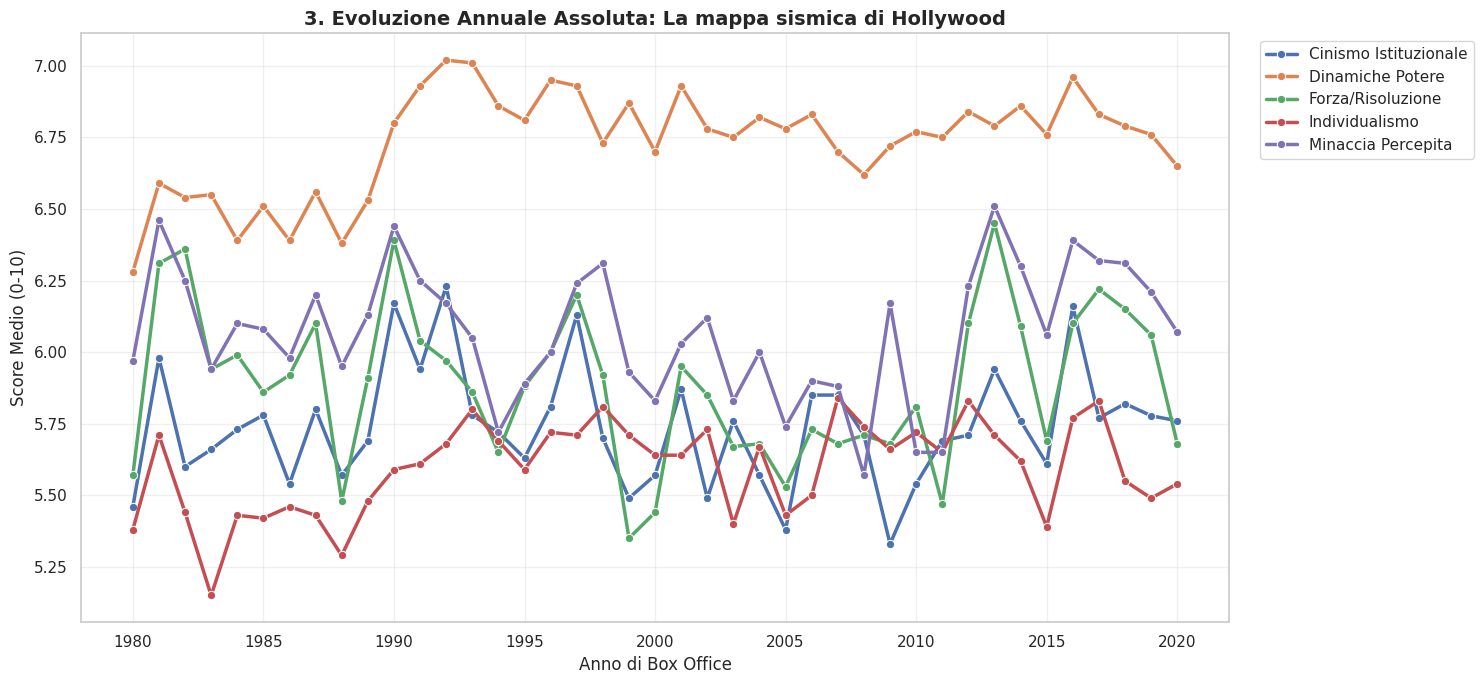

In [6]:
yearly_data = df_assoluto.groupby(['box_office_year', 'Tema'])['Score (0-10)'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=yearly_data, 
    x='box_office_year', 
    y='Score (0-10)', 
    hue='Tema', 
    linewidth=2.5, 
    marker='o'
)
plt.title('3. Evoluzione Annuale Assoluta: La mappa sismica di Hollywood', fontsize=14, fontweight='bold')
plt.ylabel('Score Medio (0-10)')
plt.xlabel('Anno di Box Office')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07A_plot3_line.png', dpi=300)
plt.show()

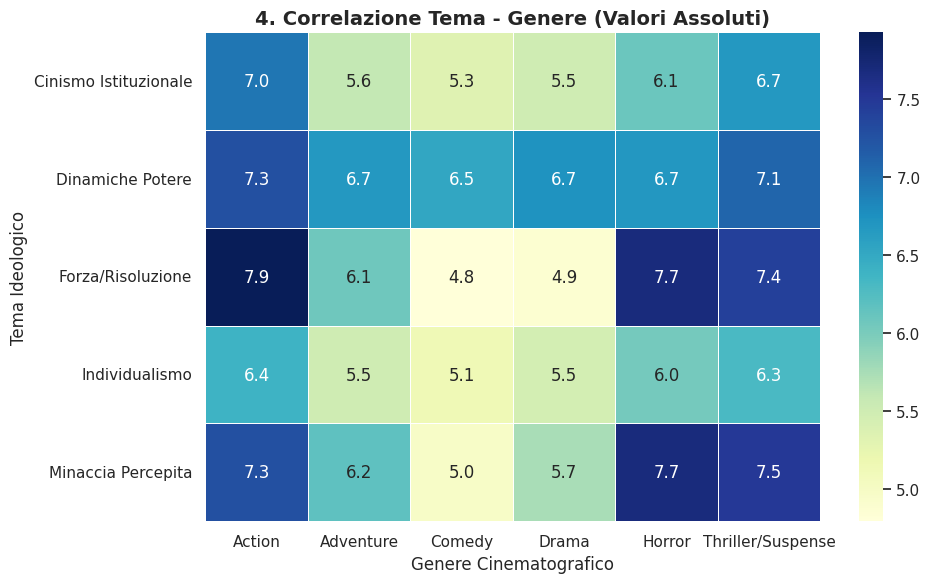

In [7]:
# Selezioniamo solo i 6 generi più frequenti per avere un grafico leggibile
generi_top = df_assoluto['genre'].value_counts().head(6).index
df_generi = df_assoluto[df_assoluto['genre'].isin(generi_top)]

heatmap_generi = df_generi.pivot_table(index='Tema', columns='genre', values='Score (0-10)', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_generi, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
plt.title('4. Correlazione Tema - Genere (Valori Assoluti)', fontsize=14, fontweight='bold')
plt.ylabel('Tema Ideologico')
plt.xlabel('Genere Cinematografico')
plt.tight_layout()
plt.savefig('07A_plot4_heatmap_generi.png', dpi=300)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e08cfdf8-9b6e-44e8-b36c-3dd235d85ba1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>